# 任务 B：RAG 农业知识库问答系统

## 学习目标
- 理解 RAG（检索增强生成）的原理与价值
- 学会从网络采集农业知识数据
- 掌握知识库构建方法
- 构建端到端的农业知识问答 Pipeline

## RAG 原理

LLM 虽然强大，但有三个关键问题：
1. **幻觉**：模型会编造看似合理但实际错误的信息
2. **知识时效性**：模型训练截止于某个时间点
3. **领域专业性**：通用模型对特定领域知识不够深入

**RAG 的解决方案**：
```
用户提问 → 检索知识库找到相关文档 → 将文档作为上下文给 LLM → LLM 基于事实生成回答
```

---
## 步骤 1：配置 API 客户端与向量模型

In [1]:
import os
import glob
from openai import OpenAI
import chromadb
from chromadb.utils import embedding_functions
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ── 配置 HuggingFace 镜像（国内用户加速下载）──
# 如果网络无法访问 huggingface.co，设置镜像端点
if os.environ.get("HF_ENDPOINT") is None:
    os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
    print("已设置 HF 镜像: https://hf-mirror.com")

# ── 配置 agicto API ──
API_KEY = os.environ.get("AGICTO_API_KEY", "sk-Fv9s4DBlAIpSgVdNdDrjFcri7N7hOMy7PzREWbPmbGqf7eVX")
BASE_URL = "https://api.agicto.cn/v1"
MODEL = "qwen-plus"

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
print(f"API 基础地址: {BASE_URL}")
print(f"使用模型: {MODEL}")

# ── 加载 BGE-M3 向量模型（支持 CPU 运行）──
# BGE-M3 是智源研究院的开源多语言模型，中英文都表现优秀
print("\n加载 BGE-M3 向量模型（首次下载约 2GB，请耐心等待）...")
embedder = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="BAAI/bge-m3"
)
print("向量模型加载完成！")

已设置 HF 镜像: https://hf-mirror.com
API 基础地址: https://api.agicto.cn/v1
使用模型: qwen-plus

加载 BGE-M3 向量模型（首次下载约 2GB，请耐心等待）...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

向量模型加载完成！


---
## 步骤 2：数据采集 — 爬取农业知识文章

使用 `requests` + `BeautifulSoup` 从中国科普网爬取番茄晚疫病防治文章，演示完整的数据采集流程。

In [2]:
# ── 爬虫脚本：从中国科普网爬取番茄晚疫病防治文章 ──
import requests
from bs4 import BeautifulSoup
import os

def fetch_page(url, encoding="utf-8"):
    """获取网页内容"""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
    }
    response = requests.get(url, headers=headers, timeout=15)
    if encoding == "auto":
        response.encoding = response.apparent_encoding
    else:
        response.encoding = encoding
    return response.text

def extract_article(html):
    """从网页中提取正文"""
    soup = BeautifulSoup(html, "html.parser")
    
    # 删除无关元素
    for tag in soup(["script", "style", "nav", "footer", "header", "aside"]):
        tag.decompose()
    
    # 尝试获取正文区域
    article = (soup.find("article") 
               or soup.find("div", class_="article-content")
               or soup.find("div", id_="content")
               or soup.find("main"))
    
    if article:
        # 提取所有段落
        paragraphs = article.find_all("p")
        text = "\n".join([p.get_text(strip=True) for p in paragraphs if p.get_text(strip=True)])
    else:
        paragraphs = soup.find_all("p")
        text = "\n".join([p.get_text(strip=True) for p in paragraphs if len(p.get_text(strip=True)) > 50])
    
    # 清理多余空行
    lines = [line.strip() for line in text.split("\n") if line.strip()]
    return "\n\n".join(lines)

# ── 爬取文章 ──
url = "http://www.kepu.gov.cn/jcsn/2025-11/28/content_439412.html"
print(f"正在爬取: {url}")

try:
    html = fetch_page(url, encoding="utf-8")
    text = extract_article(html)
    
    # 保存到 knowledge_base
    save_dir = "knowledge_base/scraped"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"{save_dir}/tomato_late_blight_scraped.md"
    
    with open(filename, "w", encoding="utf-8") as f:
        f.write(f"# 番茄晚疫病早识别，5大流行特征须记牢！\n\n")
        f.write(f"来源：北京市农业农村宣传中心\n")
        f.write(f"原文链接：{url}\n")
        f.write(f"爬取说明：使用 requests + BeautifulSoup 爬取，用于学习研究\n\n")
        f.write("---\n\n")
        f.write(text)
    
    print(f"文章已保存到: {filename}")
    print(f"内容预览:\n{text[:300]}...")
except Exception as e:
    print(f"爬取失败: {e}")
    print("提示：如果网络受限，已预先将爬取好的文章放在 knowledge_base/scraped/ 目录下")

正在爬取: http://www.kepu.gov.cn/jcsn/2025-11/28/content_439412.html
文章已保存到: knowledge_base/scraped/tomato_late_blight_scraped.md
内容预览:
番茄晚疫病是设施番茄生产中的一种重要病害，病原为疫霉菌，在番茄幼苗和成株期均可发生。该病秋冬季易发，流行速度快、破坏力大，染病后通常会对番茄生产造成严重产量损失。当前，北京市大部分越冬茬设施番茄处于开花结果期，番茄晚疫病将进入流行关键期。北京市植物保护站提醒广大蔬菜生产者全面掌握番茄晚疫病发生特点，护航番茄生产安全。

一、五大特征要记牢

1.低温高湿是“最爱”

番茄晚疫病属于典型的低温高湿型病害，10-22℃、湿度高于70%的棚室易发生流行。

2.扩散速度较快

当低温寡照天气叠加防控不力时，从出现中心病株到全田蔓延一般仅需7～15天。

3.减产程度显著

番茄晚疫病可危害叶、茎、花...


---
## 步骤 3：加载知识库文档

知识库目录结构（含爬取的文档）：
```
knowledge_base/
├── diseases/              # 病害知识
│   ├── tomato_early_blight.md
│   └── tomato_late_blight.md
├── planting/              # 种植技术
│   └── tomato_planting_guide.md
├── pesticide/             # 农药使用
│   └── common_pesticides.md
└── scraped/               # 爬虫采集
    └── tomato_late_blight_scraped.md
```

In [3]:
def load_documents(directory):
    """加载指定目录下的所有 .md / .txt 文件"""
    documents = []
    file_paths = glob.glob(os.path.join(directory, "**/*.md"), recursive=True)
    file_paths += glob.glob(os.path.join(directory, "**/*.txt"), recursive=True)

    for path in file_paths:
        with open(path, "r", encoding="utf-8") as f:
            content = f.read()
        rel_path = os.path.relpath(path, directory)
        documents.append({
            "source": rel_path,
            "content": content,
            "title": os.path.basename(path)
        })

    print(f"加载了 {len(documents)} 篇文档")
    for doc in documents:
        print(f"  - {doc['source']} ({len(doc['content'])} 字符)")
    return documents


docs = load_documents("knowledge_base")
print(f"\n文档总数: {len(docs)}")

加载了 5 篇文档
  - diseases/tomato_early_blight.md (663 字符)
  - diseases/tomato_late_blight.md (656 字符)
  - pesticide/common_pesticides.md (1114 字符)
  - planting/tomato_planting_guide.md (983 字符)
  - scraped/tomato_late_blight_scraped.md (1020 字符)

文档总数: 5


---
## 步骤 4：文档分块（Chunking）

将长文档分成合适大小的文本块，便于向量检索：
- 每块约 500 字符
- 块之间重叠 50 字符，保持上下文连贯

In [4]:
def chunk_text(text, chunk_size=500, overlap=50):
    """将长文本分成重叠的块"""
    chunks = []
    paragraphs = text.split("\n\n")

    current_chunk = ""
    for para in paragraphs:
        para = para.strip()
        if not para:
            continue

        if len(current_chunk) + len(para) < chunk_size:
            current_chunk += "\n\n" + para if current_chunk else para
        else:
            if current_chunk:
                chunks.append(current_chunk)
            words = current_chunk.split()
            overlap_text = (
                " ".join(words[-overlap:]) if len(words) > overlap else current_chunk
            )
            current_chunk = overlap_text + "\n\n" + para

    if current_chunk:
        chunks.append(current_chunk)
    return chunks


# 对所有文档分块
all_chunks = []
for doc in docs:
    chunks = chunk_text(doc["content"], chunk_size=500, overlap=50)
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "text": chunk,
            "source": doc["source"],
            "title": doc["title"],
            "chunk_id": f"{doc['source']}_{i}"
        })

print(f"共分成 {len(all_chunks)} 个文本块")
for chunk in all_chunks:
    preview = chunk["text"][:80].replace("\n", " ")
    print(f"  [{chunk['chunk_id']}] {preview}...")

共分成 41 个文本块
  [diseases/tomato_early_blight.md_0] # 番茄早疫病（Alternaria Leaf Spot）  ## 基本信息 - **病原**：链格孢菌（Alternaria solani） - **发病条件...
  [diseases/tomato_early_blight.md_1] # 番茄早疫病（Alternaria Leaf Spot）  ## 基本信息 - **病原**：链格孢菌（Alternaria solani） - **发病条件...
  [diseases/tomato_early_blight.md_2] 清除病残体，减少初侵染源 - 合理密植，改善通风透光条件 - 科学施肥，增强植株抗病力 ### 化学防治 | 药剂 | 浓度 | 用法 | 安全间隔期 | |-...
  [diseases/tomato_late_blight.md_0] # 番茄晚疫病（Late Blight）  ## 基本信息 - **病原**：致病疫霉菌（Phytophthora infestans） - **发病条件**：...
  [diseases/tomato_late_blight.md_1] # 番茄晚疫病（Late Blight）  ## 基本信息 - **病原**：致病疫霉菌（Phytophthora infestans） - **发病条件**：...
  [diseases/tomato_late_blight.md_2] 合理轮作，避免与马铃薯等茄科作物连作 - 及时清除中心病株和病叶 - 控制田间湿度，及时排水 ### 化学防治 | 药剂 | 浓度 | 用法 | 安全间隔期 |...
  [pesticide/common_pesticides.md_0] # 常用农药使用手册  ## 杀菌剂  ### 代森锰锌（Mancozeb） - **剂型**：80% 可湿性粉剂 - **防治对象**：早疫病、晚疫病、霜霉病...
  [pesticide/common_pesticides.md_1] # 常用农药使用手册  ## 杀菌剂  ### 代森锰锌（Mancozeb） - **剂型**：80% 可湿性粉剂 - **防治对象**：早疫病、晚疫病、霜霉病...
  [pesticide/comm

---
## 步骤 5：构建向量数据库

使用 ChromaDB 存储文本块的向量表示，BGE-M3 模型负责将文本转为向量。

In [5]:
# 初始化 ChromaDB（持久化存储）
chroma_client = chromadb.PersistentClient(path="./chroma_db")

collection_name = "agri_knowledge"

# 删除旧集合（如果存在），避免连接冲突
try:
    chroma_client.delete_collection(name=collection_name)
    print(f"已删除旧集合: {collection_name}")
except Exception:
    pass

# 全新创建集合
collection = chroma_client.create_collection(
    name=collection_name,
    embedding_function=embedder,
    metadata={"description": "农业知识库"}
)
print(f"创建新集合: {collection_name}")

texts = [chunk["text"] for chunk in all_chunks]
ids = [chunk["chunk_id"] for chunk in all_chunks]
metadatas = [
    {"source": chunk["source"], "title": chunk["title"]}
    for chunk in all_chunks
]

# 分批添加
batch_size = 100
for i in range(0, len(texts), batch_size):
    batch_end = min(i + batch_size, len(texts))
    collection.add(
        documents=texts[i:batch_end],
        ids=ids[i:batch_end],
        metadatas=metadatas[i:batch_end]
    )

print(f"已向量化并存储 {len(texts)} 个文本块")
print(f"集合名称: {collection_name}")
print(f"集合大小: {collection.count()}")

已删除旧集合: agri_knowledge
创建新集合: agri_knowledge
已向量化并存储 41 个文本块
集合名称: agri_knowledge
集合大小: 41


---
## 步骤 6：检索与问答

核心 RAG 流程：
1. 将用户问题向量化
2. 在向量数据库中检索最相关的文本块
3. 将检索结果作为上下文拼接进 Prompt
4. LLM 基于参考资料生成回答

In [6]:
def retrieve_and_answer(question, top_k=3, verbose=True):
    """检索相关知识并生成回答
    
    Parameters:
        question: 用户问题
        top_k: 返回最相关的文档数量
        verbose: 是否打印详细输出（对比实验时设为 False）
    """
    # ── 第一步：检索 ──
    results = collection.query(
        query_texts=[question],
        n_results=top_k
    )

    if verbose:
        print(f"\n问题: {question}")
        print(f"\n检索到的相关知识:")
        print("-" * 50)

    # 整理检索到的内容
    context_parts = []
    for i, (doc, metadata, distance) in enumerate(zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    )):
        if verbose:
            print(f"\n[来源: {metadata['source']}] (相关度: {1-distance:.2f})")
            print(f"内容: {doc[:200]}...")
        context_parts.append(f"来源: {metadata['source']}\n内容: {doc}")

    # ── 第二步：构建 prompt ──
    context = "\n\n---\n\n".join(context_parts)

    system_prompt = """你是农业植保专家。请基于以下参考资料回答用户的问题。
要求：
1. 回答必须基于参考资料，不要编造信息
2. 如果参考资料不足以回答问题，请如实告知
3. 回答要实用、有针对性
4. 在回答末尾注明参考来源"""

    user_prompt = f"""参考资料：
{context}

用户问题：{question}

请基于以上资料，给出专业、实用的回答。"""

    # ── 第三步：生成回答 ──
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    answer = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.3,
        max_tokens=1024
    ).choices[0].message.content

    if verbose:
        print(f"\n{'=' * 50}")
        print(f"AI 回答:")
        print("-" * 50)
        print(answer)
    return answer


# ── 测试多个农业问题 ──
questions = [
    "番茄早疫病的症状和防治方法是什么？",
    "番茄叶片出现褐色斑点可能是什么病？",
    "代森锰锌的使用方法和注意事项是什么？",
]

for q in questions:
    retrieve_and_answer(q, top_k=3)
    print("\n" + "=" * 60)


问题: 番茄早疫病的症状和防治方法是什么？

检索到的相关知识:
--------------------------------------------------

[来源: diseases/tomato_early_blight.md] (相关度: 0.78)
内容: # 番茄早疫病（Alternaria Leaf Spot）

## 基本信息
- **病原**：链格孢菌（Alternaria solani）
- **发病条件**：温度 20-25°C，相对湿度 80% 以上，多雨季节易发
- **危害部位**：主要危害叶片，也可危害茎秆和果实

## 症状识别
1. **叶片**：初为水渍状暗褐色小点，后扩大为圆形或近圆形病斑
2. **特征性病斑**：褐色同...

[来源: diseases/tomato_early_blight.md] (相关度: 0.78)
内容: # 番茄早疫病（Alternaria Leaf Spot）

## 基本信息
- **病原**：链格孢菌（Alternaria solani）
- **发病条件**：温度 20-25°C，相对湿度 80% 以上，多雨季节易发
- **危害部位**：主要危害叶片，也可危害茎秆和果实

## 症状识别
1. **叶片**：初为水渍状暗褐色小点，后扩大为圆形或近圆形病斑
2. **特征性病斑**：褐色同...

[来源: scraped/tomato_late_blight_scraped.md] (相关度: 0.73)
内容: # 番茄晚疫病早识别，5大流行特征须记牢！

来源：北京市农业农村宣传中心
原文链接：http://www.kepu.gov.cn/jcsn/2025-11/28/content_439412.html
爬取说明：使用 requests + BeautifulSoup 爬取，用于学习研究

---

番茄晚疫病是设施番茄生产中的一种重要病害，病原为疫霉菌，在番茄幼苗和成株期均可发生。该病秋冬季易发...

AI 回答:
--------------------------------------------------
番茄早疫病（Alternaria Leaf Spot）是由**链格孢菌（*Alternaria solani*）**引起的真菌性病害，是露地及保护

---
## 步骤 7：RAG vs 无 RAG 对比实验

对比同一个问题在有/无 RAG 情况下的回答质量差异。

【无 RAG】正在获取回答（纯 LLM，不提供参考资料）...
番茄早疫病（由真菌 *Alternaria solani* 引起）是一种常见且危害严重的叶部病害，可侵染叶片、茎和果实，典型症状为“靶标状”褐色同心轮纹病斑，常伴有黄晕，潮湿时病斑表面产生灰黑色霉层。

**防治原则：坚持“预防为主、综合防控”，药剂治疗需在发病初期及时施用，并注意轮换用药以防抗药性。**

以下是目前登记用于番茄早疫病、效果较可靠且在生产中广泛应用的推荐药剂及使用剂量（以我国农业农村部登记产品及《农药合理使用准则》为依据）：

---

✅ **一、推荐杀菌剂及使用剂量（喷雾法，常规背负式喷雾器）**

| 药剂类别 | 有效成分（商品名示例） | 推荐剂量（每亩用量） | 施用要点 |
|----------|------------------------|----------------------|-----------|
| **保护性杀菌剂** | 代森锰锌（如大生M-45、山德生） | 80%可湿性粉剂 **120–160 g** 或 70%可湿性粉剂 **100–140 g**，兑水45–60 L喷雾 | 发病前或初见病斑时使用；注意安全间隔期（≥15天），避免与碱性农药混用；对幼果有轻微药害风险，高温期慎用。 |
| **内吸治疗性杀菌剂** | 苯醚甲环唑（如世高） | 10%水分散粒剂 **40–60 g**，兑水45–60 L喷雾 | 具内吸传导性，对早期病斑有治疗作用；建议与保护剂（如代森锰锌）混用增效；最多使用2次，间隔7–10天。 |
| **复配制剂（高效、抗性风险低）** | 苯醚甲环唑·嘧菌酯（如阿米妙收） | 32.5%悬浮剂 **30–40 mL**，兑水45–60 L喷雾 | 兼具保护+治疗+铲除活性，持效期长（7–10天）；推荐

【有 RAG】正在获取回答（基于知识库检索 + LLM）...

问题: 番茄早疫病用什么药治疗？推荐剂量是多少？

检索到的相关知识:
--------------------------------------------------

[来源: diseases/tomato_early_blight.md] (相关度: 0.74)
内容: # 番茄早疫病（Alternaria Leaf Spot）

## 

/tmp/ipykernel_2114/3348610446.py:63: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2114/3348610446.py:63: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2114/3348610446.py:63: UserWarning: Glyph 23383 (\N{CJK UNIFIED IDEOGRAPH-5B57}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2114/3348610446.py:63: UserWarning: Glyph 31526 (\N{CJK UNIFIED IDEOGRAPH-7B26}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2114/3348610446.py:63: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2114/3348610446.py:63: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_2114/3348610446.py:63: UserWarning: Glyph 31572 (\N{CJK UNIFIED IDEOGRAPH-7B54}) missing from current font.
  plt.tight_l

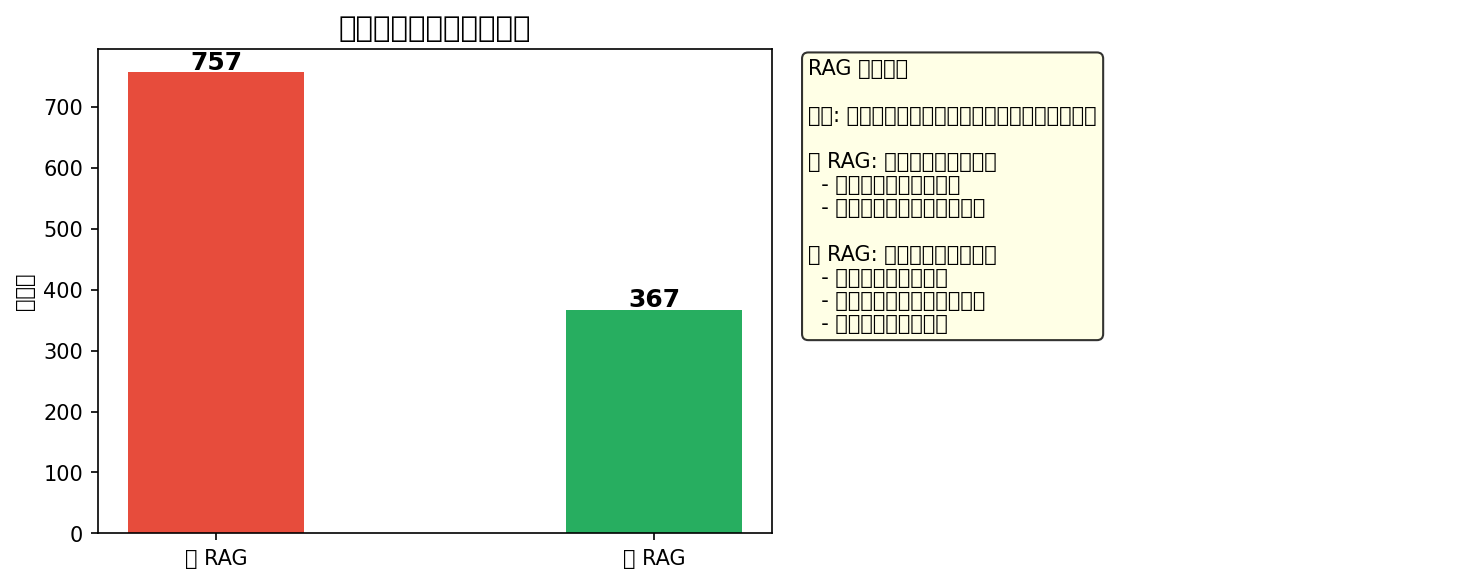


对比图已保存到 task_b_rag_comparison.png

--- 对比分析 ---
无 RAG 回答长度: 757 字符
有 RAG 回答长度: 367 字符
结论：有 RAG 的回答基于知识库文档，信息更准确、更有依据、更详细。


In [7]:
from IPython.display import Image, display

test_question = "番茄早疫病用什么药治疗？推荐剂量是多少？"

# ── 无 RAG：直接问 LLM（凭记忆回答）──
print("=" * 60)
print("【无 RAG】正在获取回答（纯 LLM，不提供参考资料）...")
print("=" * 60)
messages_no_rag = [
    {"role": "system", "content": "你是农业专家。"},
    {"role": "user", "content": test_question}
]
answer_no_rag = client.chat.completions.create(
    model=MODEL,
    messages=messages_no_rag,
    temperature=0.5,
    max_tokens=512
).choices[0].message.content

print(answer_no_rag)

# ── 有 RAG：基于知识库回答 ──
print("\n" + "=" * 60)
print("【有 RAG】正在获取回答（基于知识库检索 + LLM）...")
print("=" * 60)
answer_with_rag = retrieve_and_answer(test_question, verbose=True)

# ── 对比柱状图 ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 图 1: 回答长度对比
ax1 = axes[0]
labels = ["无 RAG", "有 RAG"]
lengths = [len(answer_no_rag), len(answer_with_rag)]
colors = ["#E74C3C", "#27AE60"]
bars = ax1.bar(labels, lengths, color=colors, width=0.4)
ax1.set_title("回答长度对比（字符数）", fontsize=14, fontweight="bold")
ax1.set_ylabel("字符数")
for bar, val in zip(bars, lengths):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", fontsize=12, fontweight="bold")

# 图 2: 简要说明
ax2 = axes[1]
ax2.axis("off")
summary_text = (
    "RAG 对比实验\n\n"
    f"问题: {test_question}\n\n"
    "无 RAG: 模型凭训练记忆回答\n"
    "  - 可能准确，也可能编造\n"
    "  - 缺少具体剂量、用法等细节\n\n"
    "有 RAG: 模型基于知识库回答\n"
    "  - 信息来自知识库文档\n"
    "  - 包含具体药剂、剂量、用法\n"
    "  - 回答更详实、可溯源"
)
ax2.text(0.02, 0.98, summary_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment="top", family="sans-serif",
         bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig("task_b_rag_comparison.png", dpi=150, bbox_inches="tight")
plt.close()

# 显示图片
display(Image("task_b_rag_comparison.png"))
print("\n对比图已保存到 task_b_rag_comparison.png")

# 结论
print("\n--- 对比分析 ---")
print(f"无 RAG 回答长度: {len(answer_no_rag)} 字符")
print(f"有 RAG 回答长度: {len(answer_with_rag)} 字符")
print("结论：有 RAG 的回答基于知识库文档，信息更准确、更有依据、更详细。")

---
## 总结与思考题

### RAG 系统架构回顾

```
知识文档 → 文本分块 → BGE-M3 向量化 → ChromaDB 存储
                                              ↓
用户提问 → BGE-M3 向量化 → 检索最相关 chunk → Prompt 拼接 → LLM 生成回答
```

### 关键技术组件

| 组件 | 技术选型 | 说明 |
|------|----------|------|
| LLM | qwen-plus (agicto API) | 云端大语言模型 |
| Embedding | BAAI/bge-m3 | 智源开源多语言向量模型 |
| 向量数据库 | ChromaDB | 轻量级，支持持久化 |
| 文档格式 | Markdown | 结构化农业知识文档 |

### 思考题

**1. RAG 系统为什么能减少 LLM 的"幻觉"问题？**

RAG 通过检索外部知识库，为 LLM 提供了可验证的参考资料。LLM 不再仅凭训练参数"回忆"信息，而是"阅读理解"给定的上下文来生成回答。即使模型对某个领域不熟悉，只要知识库中有相关内容，它就能给出准确的答案。这种方式将知识存储从模型参数中解耦出来，使得回答更加可控和可信。

**2. 文本分块的大小（chunk_size）对检索效果有什么影响？太大或太小会怎样？**

- **太小**（如 100 字）：信息碎片化，缺乏上下文，检索可能不够全面
- **太大**（如 2000 字）：包含过多无关信息，降低检索精度，也浪费 LLM 上下文窗口
- **适中**（300-800 字）：平衡信息完整性 和 检索精度，是常用范围
- 重叠（overlap）可以在一定程度上弥补分块导致的上下文断裂

**3. 如果知识库中没有相关内容，系统应该如何处理？**

系统应诚实告知用户"当前知识库中未找到相关信息"，而不是让 LLM 编造答案。同时可以建议用户提供更多信息或咨询其他渠道。在代码中可以设置相关度阈值，当检索结果的相似度低于阈值时触发此行为。

**4. 中文向量模型和英文模型有什么区别？为什么要用专门的中文模型？**

中文和英文在分词、语法、语义表达上差异很大。通用英文模型（如 all-MiniLM-L6-v2）主要针对英文优化，对中文语义的理解不够准确。BGE-M3 专门针对中英多语言场景训练，能更好地理解中文农业术语和表达方式，检索效果明显更好。

---
任务 B 完成！